In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
dataset=pd.read_csv(r"C:\Users\Administrator\Desktop\predictive-maintenance\ai4i2020.csv")

In [3]:
dataset.shape

(10000, 14)

In [4]:
dataset.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [5]:
dataset.head

<bound method NDFrame.head of         UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0         1     M14860    M                298.1                    308.6   
1         2     L47181    L                298.2                    308.7   
2         3     L47182    L                298.1                    308.5   
3         4     L47183    L                298.2                    308.6   
4         5     L47184    L                298.2                    308.7   
...     ...        ...  ...                  ...                      ...   
9995   9996     M24855    M                298.8                    308.4   
9996   9997     H39410    H                298.9                    308.4   
9997   9998     M24857    M                299.0                    308.6   
9998   9999     H39412    H                299.0                    308.7   
9999  10000     M24859    M                299.0                    308.7   

      Rotational speed [rpm]  Torque [Nm]  To

In [6]:
dataset

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [7]:
failure=dataset[dataset["Machine failure"]==1]

In [8]:
failure

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
50,51,L47230,L,298.9,309.1,2861,4.6,143,1,0,0,1,0,0
69,70,L47249,L,298.9,309.0,1410,65.7,191,1,0,0,1,1,0
77,78,L47257,L,298.8,308.9,1455,41.3,208,1,1,0,0,0,0
160,161,L47340,L,298.4,308.2,1282,60.7,216,1,0,0,0,1,0
161,162,L47341,L,298.3,308.1,1412,52.3,218,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9758,9759,L56938,L,298.6,309.8,2271,16.2,218,1,1,0,0,0,0
9764,9765,L56944,L,298.5,309.5,1294,66.7,12,1,0,0,1,0,0
9822,9823,L57002,L,298.5,309.4,1360,60.9,187,1,0,0,0,1,0
9830,9831,L57010,L,298.3,309.3,1337,56.1,206,1,0,0,0,1,0


In [9]:
failure.shape

(339, 14)

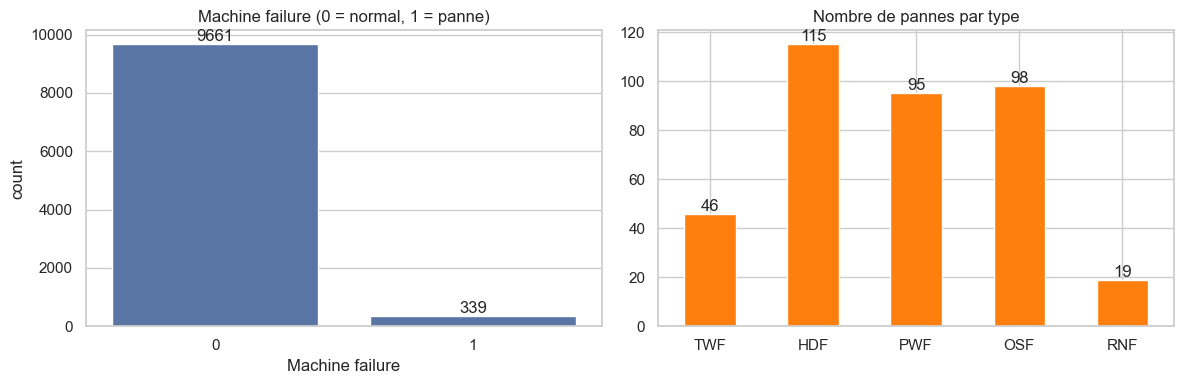

In [20]:


sns.set_theme(style="whitegrid")

features = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
fail_types = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

# ---------- 1 et 2 : déséquilibre de la cible et des types de pannes ----------
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x="Machine failure", data=dataset, ax=ax[0])
ax[0].set_title("Machine failure (0 = normal, 1 = panne)")
ax[0].bar_label(ax[0].containers[0])

dataset[fail_types].sum().plot(kind="bar", ax=ax[1], color="tab:orange")
ax[1].set_title("Nombre de pannes par type")
ax[1].bar_label(ax[1].containers[0])
ax[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()










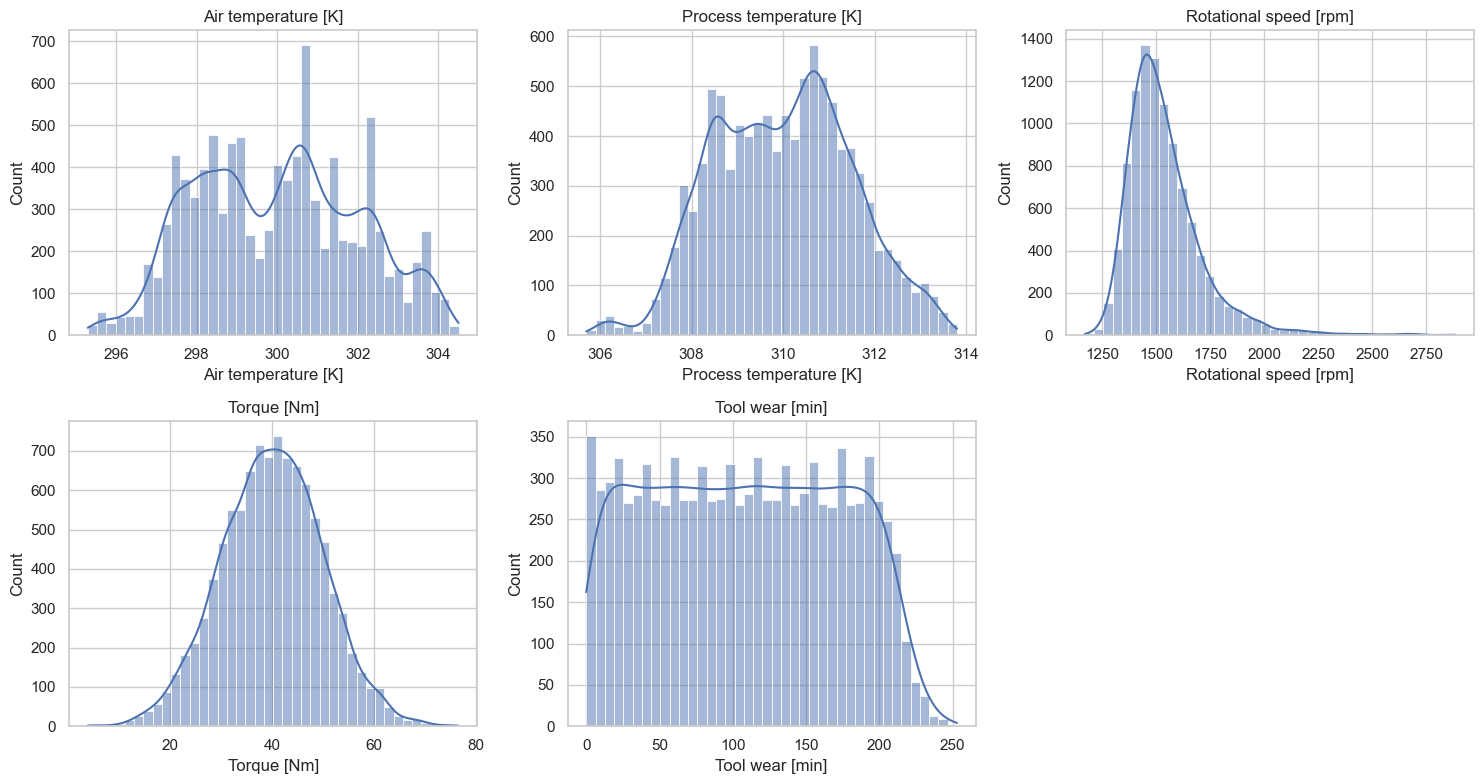

In [15]:
# ---------- 3 : histogrammes des capteurs ----------
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, features):
    sns.histplot(dataset[col], bins=40, kde=True, ax=ax)
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

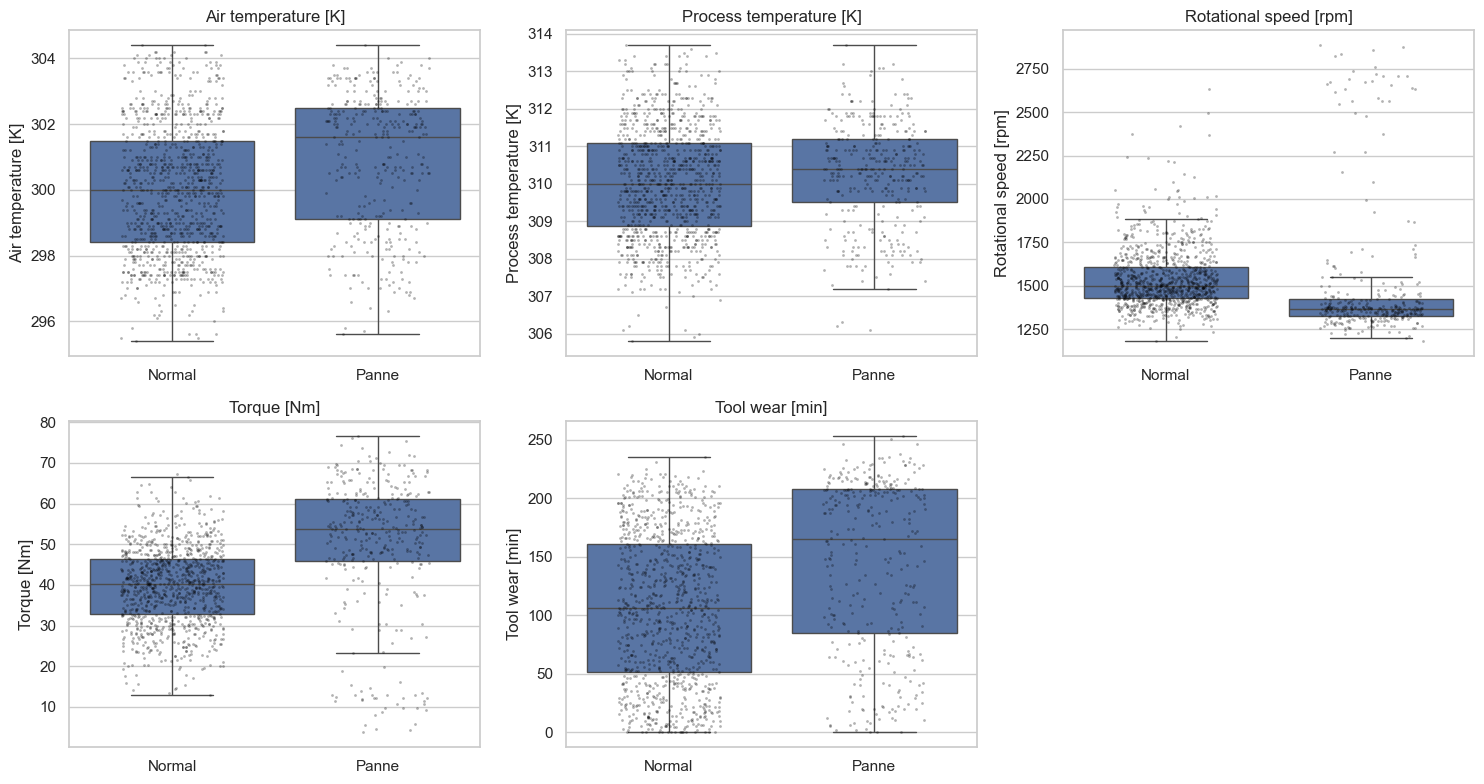

In [16]:
# ---------- 4 : boxplots + points, selon l'état de la machine ----------
normal = dataset[dataset["Machine failure"] == 0].sample(1000, random_state=0)
panne = dataset[dataset["Machine failure"] == 1]
plot_df = pd.concat([normal, panne])
plot_df["État"] = plot_df["Machine failure"].map({0: "Normal", 1: "Panne"})

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, features):
    sns.boxplot(x="État", y=col, data=plot_df, ax=ax, showfliers=False)
    sns.stripplot(x="État", y=col, data=plot_df, ax=ax,
                  alpha=0.3, size=2, jitter=0.25, color="black")
    ax.set_title(col)
    ax.set_xlabel("")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

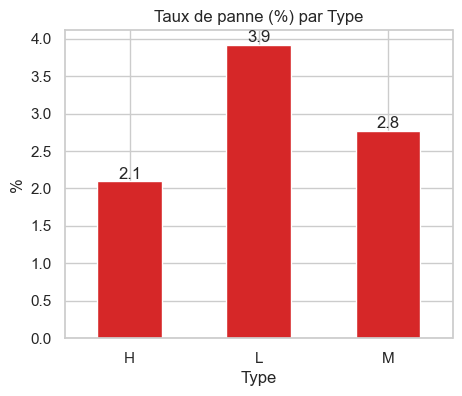

In [17]:
# ---------- 5 : taux de panne selon le Type (L, M, H) ----------
rate = dataset.groupby("Type")["Machine failure"].mean() * 100
ax = rate.plot(kind="bar", color="tab:red", figsize=(5, 4))
ax.set_title("Taux de panne (%) par Type")
ax.set_ylabel("%")
ax.bar_label(ax.containers[0], fmt="%.1f")
ax.tick_params(axis="x", rotation=0)
plt.show()

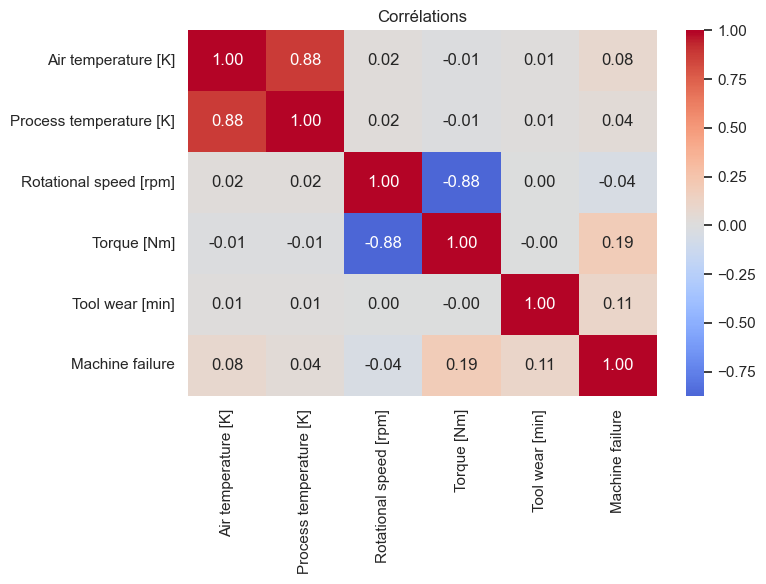

In [18]:
# ---------- 6 : matrice de corrélation ----------
corr = dataset[features + ["Machine failure"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélations")
plt.tight_layout()
plt.show()


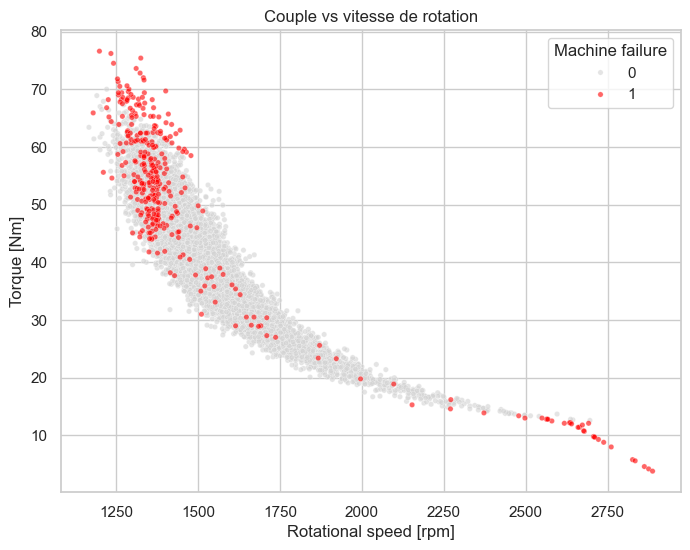

In [19]:
# ---------- 7 : couple vs vitesse, pannes en couleur ----------
plt.figure(figsize=(8, 6))
sns.scatterplot(data=dataset.sort_values("Machine failure"),
                x="Rotational speed [rpm]", y="Torque [Nm]",
                hue="Machine failure", palette={0: "lightgray", 1: "red"},
                alpha=0.6, s=15)
plt.title("Couple vs vitesse de rotation")
plt.show()

In [22]:
dataset["Machine failure"].value_counts()
dataset["Machine failure"].value_counts(normalize=True)

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

In [23]:
dataset["Type"] = dataset["Type"].map({
    "L": 0,
    "M": 1,
    "H": 2
})

In [24]:
dataset

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,0,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,0,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,0,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,0,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,1,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,2,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,1,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,2,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [26]:
dataset["Type"].value_counts()


Type
0    6000
1    2997
2    1003
Name: count, dtype: int64

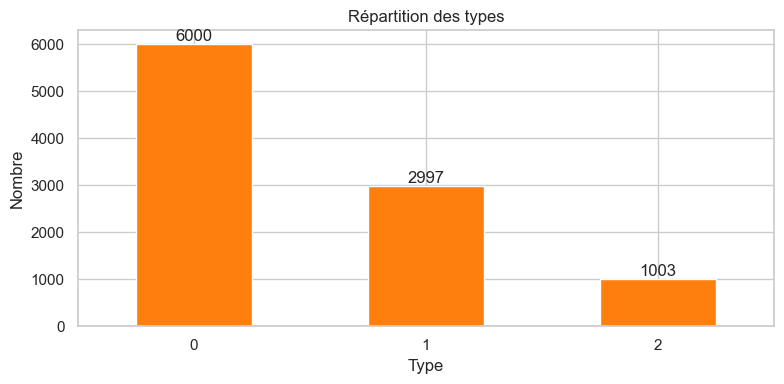

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))

dataset["Type"].value_counts().plot(
    kind="bar",
    ax=ax,
    color="tab:orange"
)

ax.set_title("Répartition des types")
ax.set_xlabel("Type")
ax.set_ylabel("Nombre")
ax.bar_label(ax.containers[0])
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

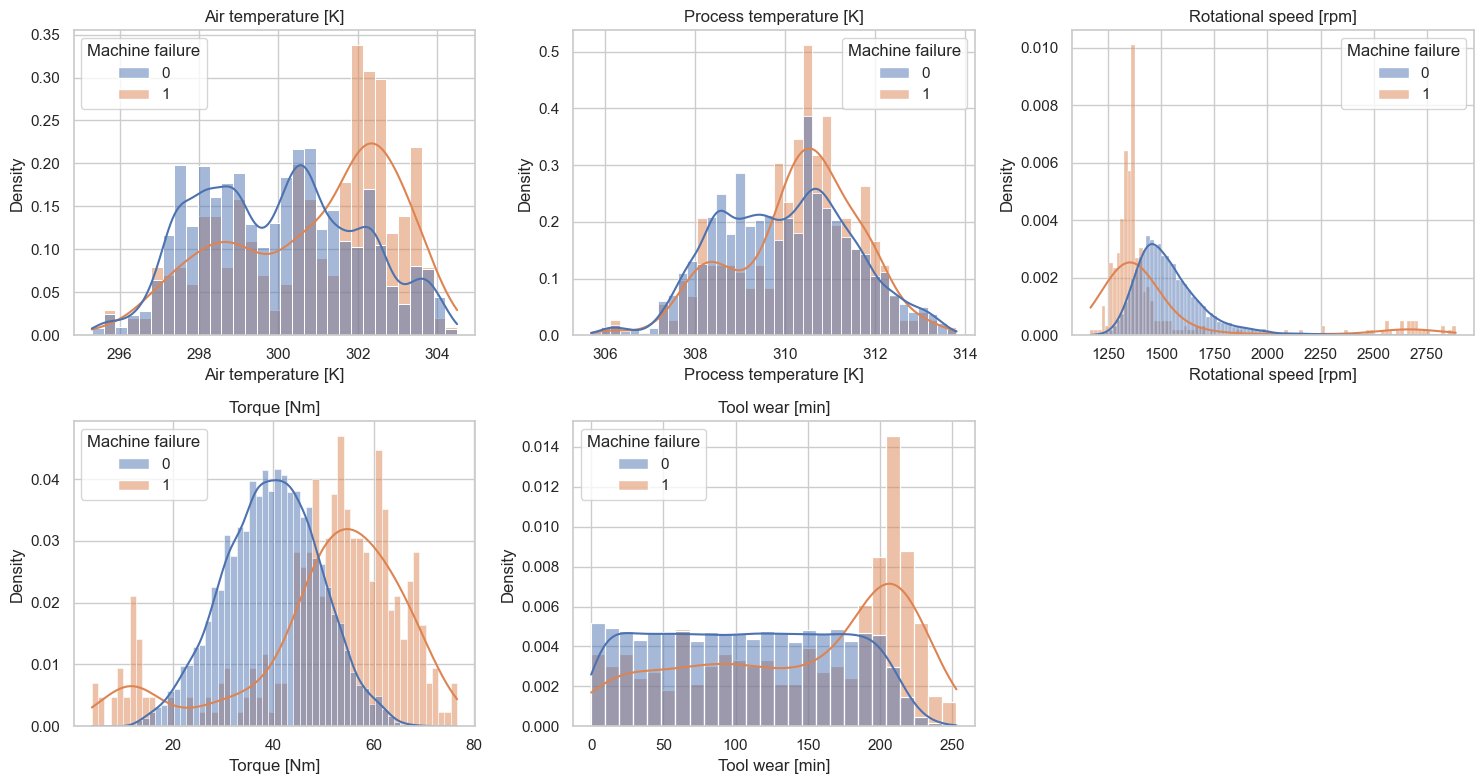

In [33]:



fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, features):
    sns.histplot(
        data=dataset,
        x=col,
        hue="Machine failure",
        kde=True,
        stat="density",
        common_norm=False,
        ax=ax
    )
    
    ax.set_title(col)

# Cacher le 6e graphique vide
axes.flat[-1].axis("off")

plt.tight_layout()
plt.show()

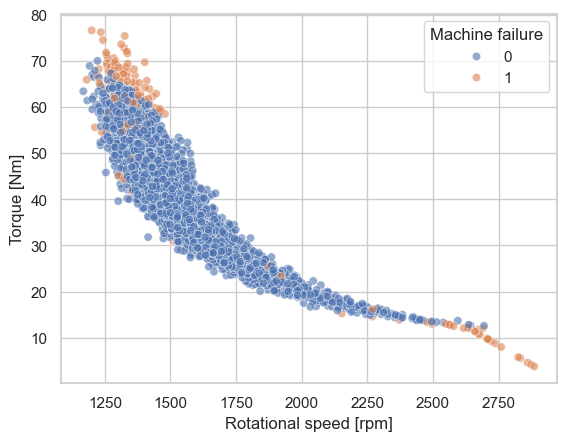

In [35]:
sns.scatterplot(
    data=dataset,
    x="Rotational speed [rpm]",
    y="Torque [Nm]",
    hue="Machine failure",
    alpha=0.6
)

plt.show()

In [40]:
dataset["Power"] = (
    dataset["Torque [Nm]"]
    * 2 * np.pi
    * dataset["Rotational speed [rpm]"]
    / 60
)

In [43]:
dataset

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Power
0,1,M14860,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,6951.590560
1,2,L47181,0,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,6826.722724
2,3,L47182,0,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,7749.387543
3,4,L47183,0,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,5927.504659
4,5,L47184,0,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,5897.816608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,1,298.8,308.4,1604,29.5,14,0,0,0,0,0,0,4955.129373
9996,9997,H39410,2,298.9,308.4,1632,31.8,17,0,0,0,0,0,0,5434.703963
9997,9998,M24857,1,299.0,308.6,1645,33.4,22,0,0,0,0,0,0,5753.617506
9998,9999,H39412,2,299.0,308.7,1408,48.5,25,0,0,0,0,0,0,7151.102638


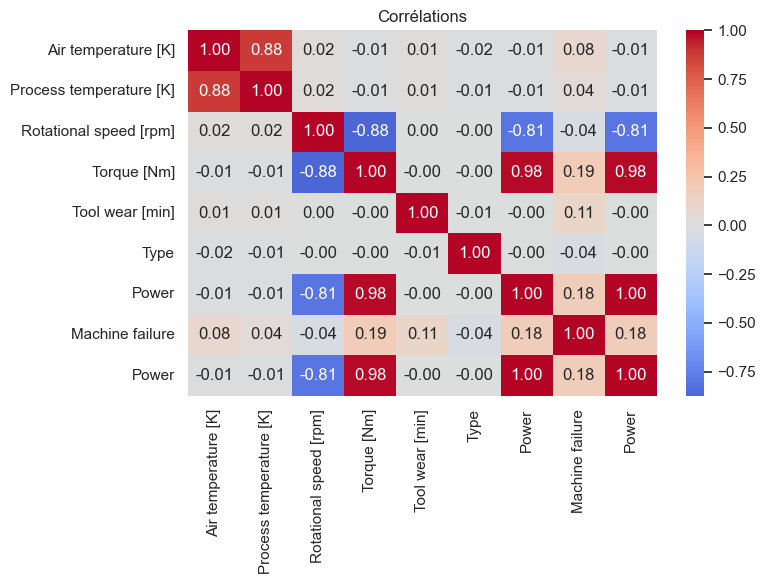

In [45]:
corr = dataset[features + ["Machine failure"]+["Power"]].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Corrélations")
plt.tight_layout()
plt.show()

In [41]:
y = dataset["Machine failure"]

In [42]:
features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Type","Power"
]

X = dataset[features]

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [47]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1585  347]
 [  12   56]]
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000



<Axes: >

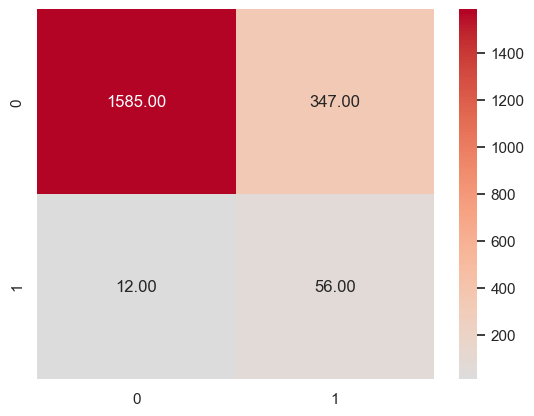

In [48]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt=".2f", cmap="coolwarm", center=0)

In [49]:
y_proba = model.predict_proba(X_test_scaled)[:, 1]


Threshold = 0.3
[[1300  632]
 [   5   63]]
              precision    recall  f1-score   support

           0       1.00      0.67      0.80      1932
           1       0.09      0.93      0.17        68

    accuracy                           0.68      2000
   macro avg       0.54      0.80      0.48      2000
weighted avg       0.97      0.68      0.78      2000


Threshold = 0.5
[[1585  347]
 [  12   56]]
              precision    recall  f1-score   support

           0       0.99      0.82      0.90      1932
           1       0.14      0.82      0.24        68

    accuracy                           0.82      2000
   macro avg       0.57      0.82      0.57      2000
weighted avg       0.96      0.82      0.88      2000


Threshold = 0.6
[[1696  236]
 [  16   52]]
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      1932
           1       0.18      0.76      0.29        68

    accuracy                           0.87      2

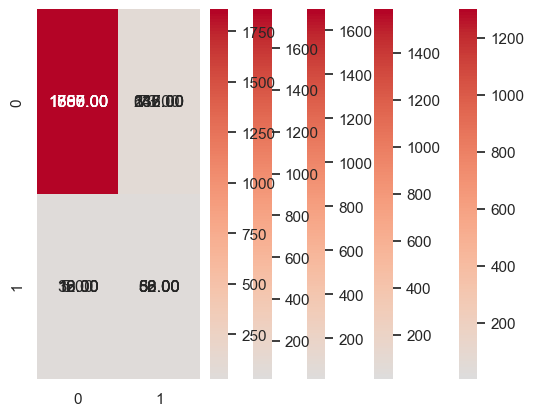

In [51]:
for threshold in [0.3, 0.5, 0.6, 0.7, 0.8]:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    print(f"\nThreshold = {threshold}")
    print(confusion_matrix(y_test, y_pred_threshold))
    sns.heatmap(confusion_matrix(y_test, y_pred_threshold), annot=True, fmt=".2f", cmap="coolwarm", center=0)
    print(classification_report(y_test, y_pred_threshold))

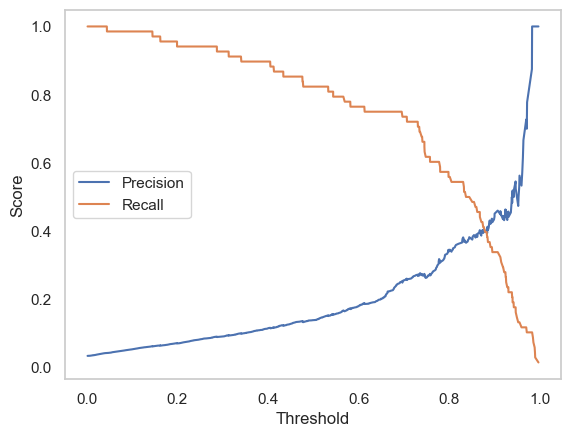

In [52]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_proba
)

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

In [53]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [54]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_tree = tree.predict(X_test)

print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

[[1799  133]
 [   8   60]]
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1932
           1       0.31      0.88      0.46        68

    accuracy                           0.93      2000
   macro avg       0.65      0.91      0.71      2000
weighted avg       0.97      0.93      0.95      2000



<Axes: >

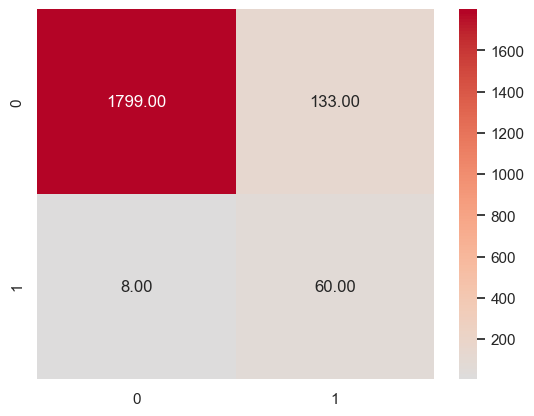

In [55]:
sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt=".2f", cmap="coolwarm", center=0)

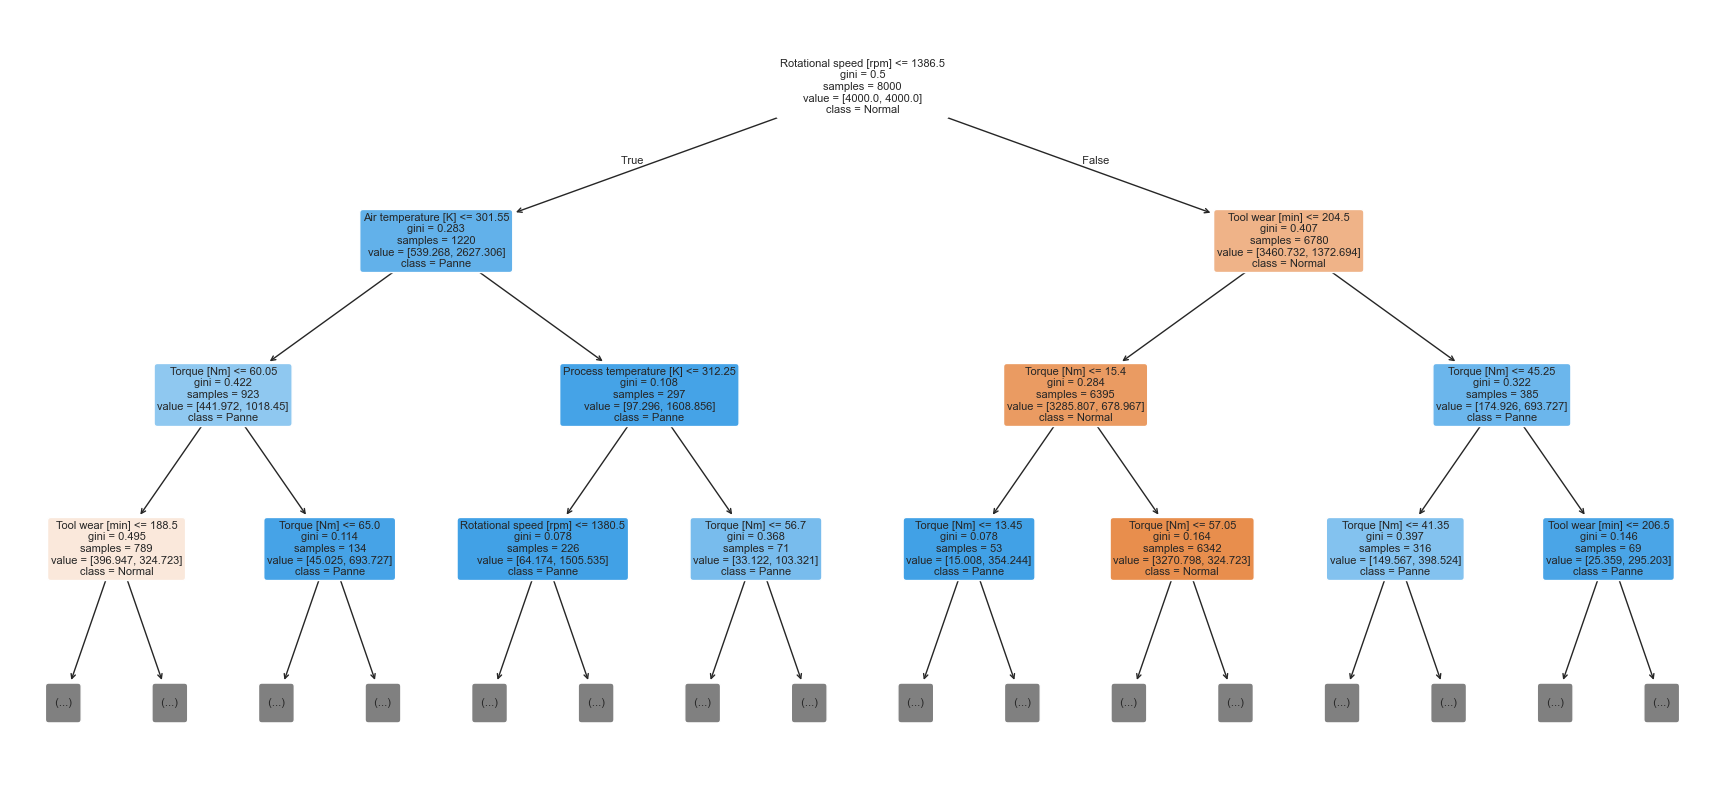

In [56]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(22, 10))

plot_tree(
    tree,
    feature_names=X_train.columns,
    class_names=["Normal", "Panne"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.show()

In [57]:
from sklearn.ensemble import RandomForestClassifier


# Création du modèle
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

# Entraînement
rf.fit(X_train, y_train)

# Prédiction
y_pred_rf = rf.predict(X_test)

# Évaluation
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[1793  139]
 [   6   62]]
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1932
           1       0.31      0.91      0.46        68

    accuracy                           0.93      2000
   macro avg       0.65      0.92      0.71      2000
weighted avg       0.97      0.93      0.94      2000



In [58]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Meilleurs paramètres :", grid.best_params_)
print("Meilleur F1 CV :", grid.best_score_)

Meilleurs paramètres : {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Meilleur F1 CV : 0.7356653571459025


In [59]:
best_rf = grid.best_estimator_

y_pred = best_rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1923    9]
 [  20   48]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.84      0.71      0.77        68

    accuracy                           0.99      2000
   macro avg       0.92      0.85      0.88      2000
weighted avg       0.98      0.99      0.98      2000



In [60]:
print("Meilleurs paramètres :", grid.best_params_)
print("F1 moyen en CV :", grid.best_score_)

Meilleurs paramètres : {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
F1 moyen en CV : 0.7356653571459025


Torque [Nm]                0.336228
Rotational speed [rpm]     0.282315
Tool wear [min]            0.209986
Air temperature [K]        0.097427
Process temperature [K]    0.061091
Type                       0.012953
dtype: float64


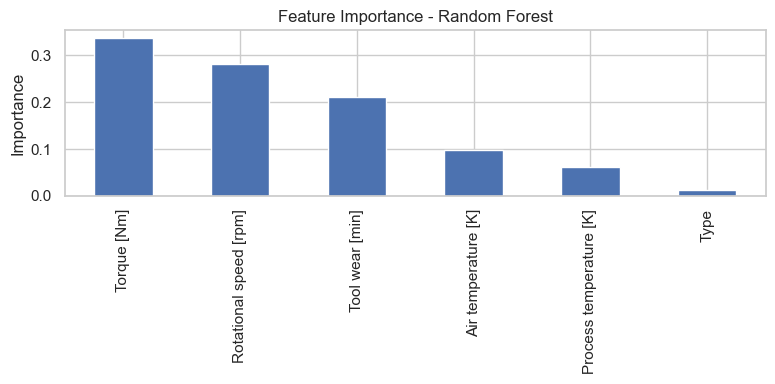

In [61]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importance)

importance.plot(kind="bar", figsize=(8, 4))

plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

Average Precision : 0.7981555030746346


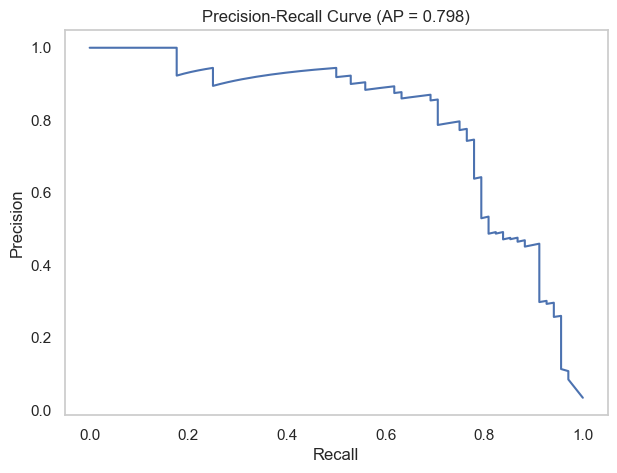

In [62]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt


y_proba = best_rf.predict_proba(X_test)[:, 1]


precision, recall, thresholds = precision_recall_curve(
    y_test, y_proba
)


ap = average_precision_score(y_test, y_proba)

print("Average Precision :", ap)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {ap:.3f})")
plt.grid()

plt.show()

In [63]:
import joblib

joblib.dump(best_rf, "machine_failure_model.pkl")

['machine_failure_model.pkl']

In [64]:
new_machine = pd.DataFrame([{
    "Air temperature [K]": 302.1,
    "Process temperature [K]": 311.2,
    "Rotational speed [rpm]": 1350,
    "Torque [Nm]": 58,
    "Tool wear [min]": 190,
    "Type": 1
}])

In [65]:
prediction = best_rf.predict(new_machine)

print(prediction)

[0]


In [66]:
proba = best_rf.predict_proba(new_machine)[0, 1]

print(f"Risque de panne : {proba:.2%}")

Risque de panne : 39.03%
